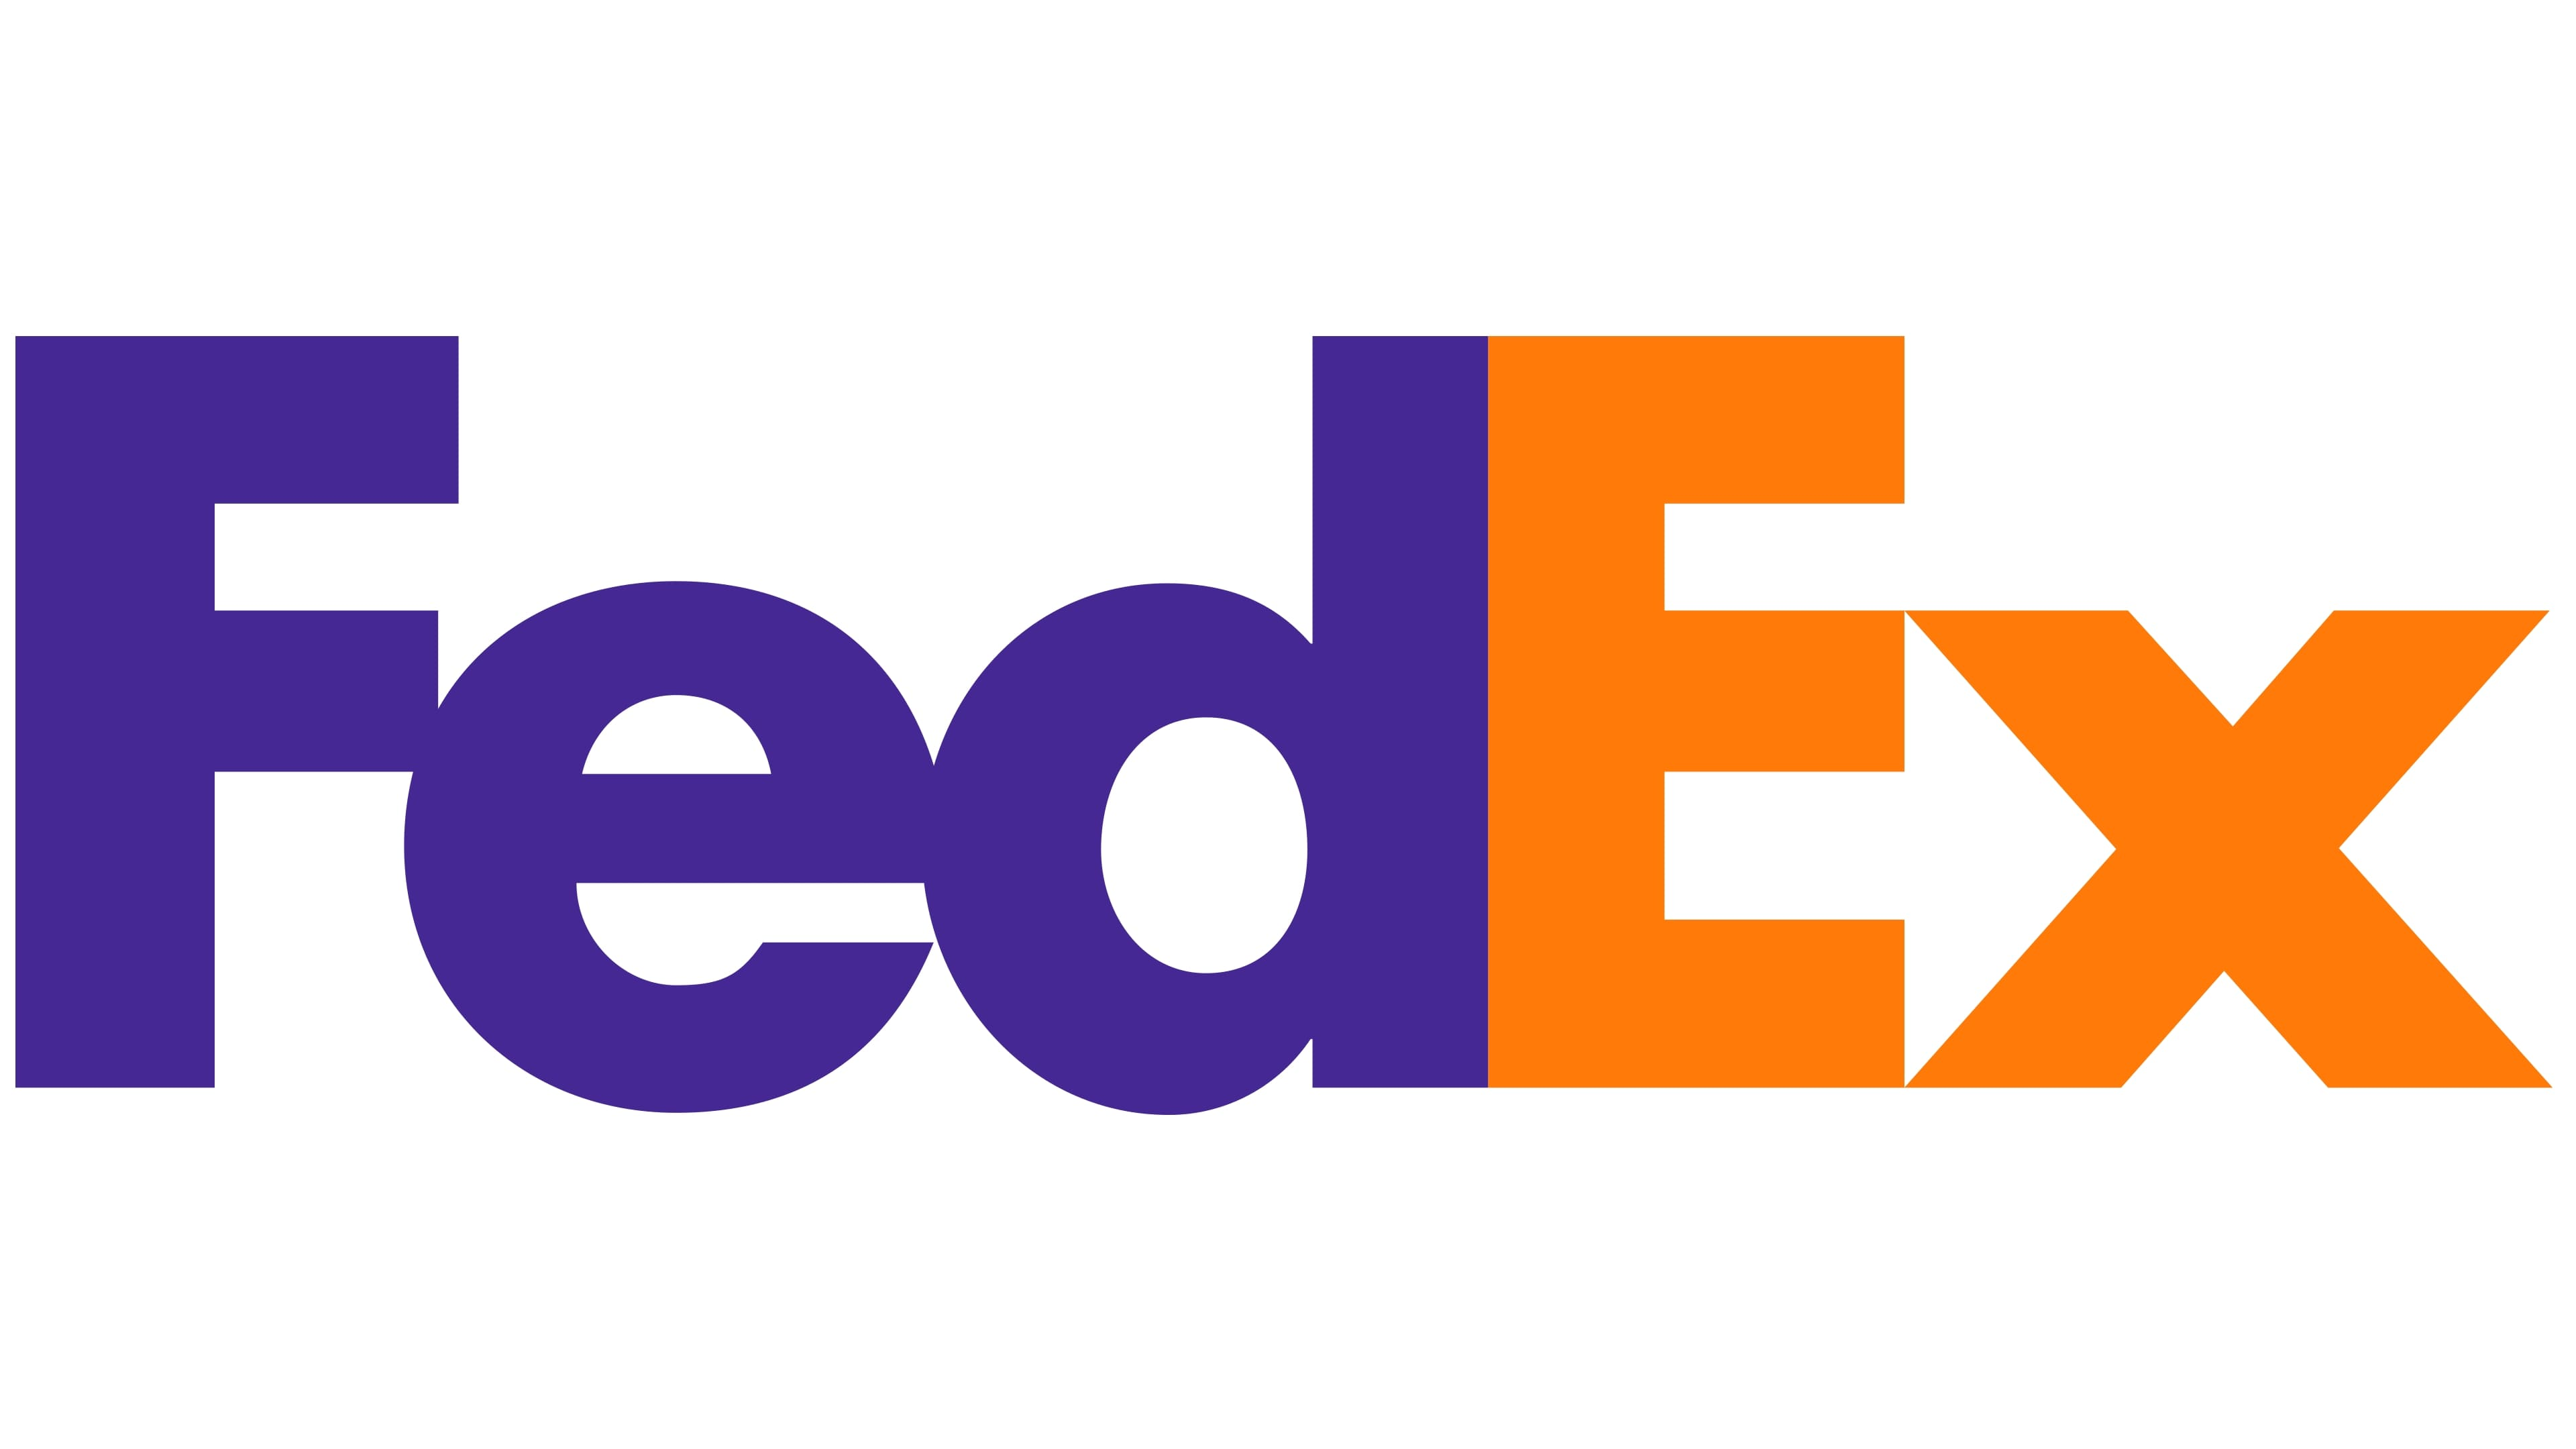

#**FedEx Logistics Supply Chain Analysis**
##Project Type
Exploratory Data Analysis (EDA)
##Team Member
Sakshi Chore

##Github Link
https://github.com/sakshi200-code/fedex-logistics-supply-chain-analysis

##Project Summary
This project analyzes the FedEx Supply Chain Management (SCMS) Delivery History dataset to understand shipment performance, delivery efficiency, freight costs, vendor performance, and logistics operations across multiple countries. The analysis explores shipment modes, delivery delays, freight expenses, product categories, vendor agreements, and transportation methods.

The objective is to identify operational bottlenecks, uncover factors affecting delivery performance, and generate business recommendations that help improve supply chain efficiency while reducing logistics costs.

Python libraries such as Pandas, NumPy, Matplotlib, Seaborn, and Plotly are used for data cleaning, exploratory data analysis, visualization, and business insight generation.

A SQLite SQL layer converts the cleaned shipment table into auditable business metrics before the visual EDA, so the charts build on clearly defined operational questions.


## Project Objective

The objective of this project is to analyze global pharmaceutical shipment operations to identify patterns affecting logistics efficiency, delivery performance, procurement, and transportation costs.

##Import Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot Style
sns.set_style("whitegrid")

plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

print("Libraries Imported Successfully")

Libraries Imported Successfully


##Load Dataset

In [2]:
#Load Dataset
df = pd.read_csv("/content/SCMS_Delivery_History_Dataset.csv")

#First five rows
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [3]:
#Shape
df.shape

(10324, 33)

In [4]:
#Columns
df.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

In [5]:
#Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [6]:
#statistical summary
df.describe()

,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


In [7]:
#Duplicated Rows
df.duplicated().sum()

np.int64(0)

In [8]:
#Missing Values
df.isnull().sum()

,0
ID,0
Project Code,0
PQ #,0
PO / SO #,0
ASN/DN #,0
Country,0
Managed By,0
Fulfill Via,0
Vendor INCO Term,0
Shipment Mode,360


#Data Cleaning

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# check the unique values in the important columns:
df["Shipment Mode"].value_counts(dropna = False)

,count
Shipment Mode,
Air,6113
Truck,2830
Air Charter,650
Ocean,371
NaN,360


In [11]:
df["Dosage"].value_counts(dropna = False).head(20)

,count
Dosage,
NaN,1736
300mg,990
200mg,932
600mg,772
150/300mg,600
150/300/200mg,580
10mg/ml,552
150mg,431
200/50mg,395


In [12]:
df["Weight (Kilograms)"].unique()[:20]

array(['13', '358', '171', '1855', '7590', '504', '328', '1478',
       'See ASN-93 (ID#:1281)', '643', '853',
       'Weight Captured Separately', '7416', '256', '710', '162', '341',
       '2278', '2126', '941'], dtype=object)

In [13]:
df["Freight Cost (USD)"].unique()[:20]

array(['780.34', '4521.5', '1653.78', '16007.06', '45450.08', '5920.42',
       'Freight Included in Commodity Cost', '6212.41',
       'See ASN-93 (ID#:1281)', '13569.49', 'Invoiced Separately',
       '64179.42', '1760.32', '3120.7', '912.96', '2682.47', '15893.71',
       '4193.49', '1767.38', '3518.38'], dtype=object)

In [14]:
#Convert to Date columns
date_columns = ["PQ First Sent to Client Date"  ,
   "PO Sent to Vendor Date"   ,
  "Scheduled Delivery Date"  ,
  "Delivered to Client Date" ,
  "Delivery Recorded Date"]

for col in date_columns:
  df[col] = pd.to_datetime(df[col] , errors = "coerce")

df[date_columns].dtypes


,0
PQ First Sent to Client Date,datetime64[ns]
PO Sent to Vendor Date,datetime64[ns]
Scheduled Delivery Date,datetime64[ns]
Delivered to Client Date,datetime64[ns]
Delivery Recorded Date,datetime64[ns]


In [15]:
# Handle Shipment Mode
df["Shipment Mode"] = df["Shipment Mode"].fillna("Unknown")
#verify
df["Shipment Mode"].isnull().sum()

np.int64(0)

In [16]:
#Convert Weight to Numeric
df["Weight (Kilograms)"] = pd.to_numeric(df["Weight (Kilograms)"], errors = "coerce")
#check
df["Weight (Kilograms)"].isnull().sum()

np.int64(3952)

In [17]:
# Convert Freight Cost
df["Freight Cost (USD)"] = pd.to_numeric(df["Freight Cost (USD)"], errors = "coerce")
#check
df["Freight Cost (USD)"].isnull().sum()

np.int64(4126)

In [18]:
#Inspect the missing data
#Missing values after cleaning
df.isnull().sum().sort_values(ascending = False)

,0
PO Sent to Vendor Date,5732
Freight Cost (USD),4126
Weight (Kilograms),3952
PQ First Sent to Client Date,2681
Dosage,1736
Line Item Insurance (USD),287
ID,0
Project Code,0
PQ #,0
Vendor INCO Term,0


In [19]:
#calculate the percentage of missing values:
missing_percentage = (df.isnull().sum()/ len(df)) *100
missing_df = pd.DataFrame({ "Missing Values": df.isnull().sum() ,
                             "Percentage" :  missing_percentage  })
missing_df.sort_values(by = "Percentage" , ascending = False)

,Missing Values,Percentage
PO Sent to Vendor Date,5732,55.521116
Freight Cost (USD),4126,39.965130
Weight (Kilograms),3952,38.279737
PQ First Sent to Client Date,2681,25.968617
Dosage,1736,16.815188
Line Item Insurance (USD),287,2.779930
ID,0,0.000000
Project Code,0,0.000000
PQ #,0,0.000000
Vendor INCO Term,0,0.000000


#Missing Value Treatment

In [20]:
# Fill missing insuarnce cost with 0
df["Line Item Insurance (USD)"] = df["Line Item Insurance (USD)"].fillna(0)
#Verify
df["Line Item Insurance (USD)"].isnull().sum()

np.int64(0)

#Feature Engineering

In [21]:
#Delivery Delay
df["Delivery Delay (Days)"] = (df["Delivered to Client Date"] - df["Scheduled Delivery Date"]).dt.days

In [22]:
#Order Processing Time
#This measures how many days it took between sending the PO to the vendor and the scheduled delivery.
df["Processing Time (Days)"] = (df["Scheduled Delivery Date"]- df["PO Sent to Vendor Date"]).dt.days
#Some values will remain NaN because the PO date itself is missing, and that's expected.

In [23]:
# On-Time vs Delayed Delivery
# Missing delivery dates are not delivery-performance outcomes, so retain them as Unknown.
df["Delivery Status"] = np.select(
    [
        df["Delivery Delay (Days)"].isna(),
        df["Delivery Delay (Days)"] <= 0,
    ],
    ["Unknown", "On Time"],
    default="Delayed",
)

# Verify the status split
df["Delivery Status"].value_counts(dropna=False)


,count
Delivery Status,
On Time,9138
Delayed,1186


In [24]:
#Delivery Months
df["Delivery Month"] =df["Delivered to Client Date"].dt.month_name()

In [25]:
#Delivery Year
df["Delivery Year"] = df["Delivered to Client Date"].dt.year

In [26]:
#Verify the columns
df[[
    "Delivery Delay (Days)",
    "Processing Time (Days)",
    "Delivery Status",
    "Delivery Month",
    "Delivery Year"
]].head()

,Delivery Delay (Days),Processing Time (Days),Delivery Status,Delivery Month,Delivery Year
0,0,NaN,On Time,June,2006
1,0,NaN,On Time,November,2006
2,0,NaN,On Time,August,2006
3,0,NaN,On Time,September,2006
4,0,NaN,On Time,August,2006


# SQL Analysis

This is the decision layer between data preparation and visual EDA. The cleaned `shipments` table is queried with SQLite to calculate auditable operational metrics: freight-cost concentration, delivery performance, supplier efficiency, seasonality, and annual country rankings. The EDA that follows visualizes and investigates these SQL-defined business questions.


In [27]:
# Load the feature-engineered DataFrame into an in-memory SQLite database.
# sqlite3 is part of Python's standard library, so this layer adds no package dependency.
import sqlite3

sql_required_columns = {
    "Country",
    "Shipment Mode",
    "Vendor",
    "Freight Cost (USD)",
    "Delivery Delay (Days)",
    "Delivery Status",
    "Delivery Month",
    "Delivery Year",
}
missing_sql_columns = sql_required_columns.difference(df.columns)
if missing_sql_columns:
    raise KeyError(f"SQL layer requires missing columns: {sorted(missing_sql_columns)}")

conn = sqlite3.connect(":memory:")
_ = df.to_sql("shipments", conn, index=False, if_exists="replace")
sql_row_count = pd.read_sql_query("SELECT COUNT(*) AS row_count FROM shipments", conn).loc[0, "row_count"]
assert sql_row_count == len(df), "SQLite row count does not match the cleaned DataFrame."
print(f"SQLite table 'shipments' created successfully with {sql_row_count:,} rows.")


SQLite table 'shipments' created successfully with 10,324 rows.


## SQL KPI snapshot

**Why this query:** Establishes a reproducible baseline for the size, delivery performance, and freight spend of the cleaned shipment population before segmenting it.

**Business impact:** Gives stakeholders a single validated starting point for the deeper SQL questions and the EDA charts below.


In [28]:
sql_kpi_snapshot = pd.read_sql_query("""
SELECT
    COUNT(*) AS total_shipments,
    SUM(CASE WHEN "Delivery Status" = 'On Time' THEN 1 ELSE 0 END) AS on_time_shipments,
    SUM(CASE WHEN "Delivery Status" = 'Delayed' THEN 1 ELSE 0 END) AS delayed_shipments,
    SUM(CASE WHEN "Delivery Status" = 'Unknown' THEN 1 ELSE 0 END) AS unassessed_shipments,
    ROUND(AVG("Delivery Delay (Days)"), 2) AS avg_delivery_delay_days,
    ROUND(SUM("Freight Cost (USD)"), 2) AS total_freight_cost_usd
FROM shipments;
""", conn)
sql_kpi_snapshot


,total_shipments,on_time_shipments,delayed_shipments,unassessed_shipments,avg_delivery_delay_days,total_freight_cost_usd
0,10324,9138,1186,0,-6.02,68817849.41


## 1. Which countries account for the most freight spend?

**Why this query:** Concentrates cost-management attention on destination countries with the largest cumulative freight outlay.

**Insight to interpret:** The countries at the top of this ranking are the priority markets for freight-rate negotiation, consolidation, or routing reviews.

**Business impact:** Focuses cost optimization on material spend rather than shipment volume alone.


In [29]:
sql_country_freight = pd.read_sql_query("""
SELECT
    Country,
    ROUND(SUM("Freight Cost (USD)"), 2) AS total_freight_cost_usd,
    COUNT(*) AS shipment_count
FROM shipments
WHERE "Freight Cost (USD)" IS NOT NULL
  AND Country IS NOT NULL
  AND TRIM(Country) <> ''
GROUP BY Country
ORDER BY total_freight_cost_usd DESC
LIMIT 10;
""", conn)
sql_country_freight


,Country,total_freight_cost_usd,shipment_count
0,Nigeria,14268550.39,764
1,Zambia,6310437.21,517
2,Côte d'Ivoire,6092165.51,729
3,Rwanda,5893493.23,350
4,Uganda,5484292.24,564
5,Tanzania,4827989.32,412
6,Zimbabwe,4318000.86,319
7,Haiti,4000498.93,396
8,Mozambique,3294121.06,365
9,Vietnam,2737277.29,446


## 2. Which shipment modes have the greatest delivery delay?

**Why this query:** Compares transportation modes on delay only where a delivery outcome can be assessed.

**Insight to interpret:** Modes with high average delay and a meaningful shipment count deserve operational investigation before expanding their use.

**Business impact:** Supports service-level decisions with a performance metric, not cost or volume in isolation.


In [30]:
sql_mode_delay = pd.read_sql_query("""
SELECT
    "Shipment Mode" AS shipment_mode,
    ROUND(AVG("Delivery Delay (Days)"), 2) AS avg_delivery_delay_days,
    COUNT(*) AS assessed_shipment_count
FROM shipments
WHERE "Delivery Delay (Days)" IS NOT NULL
GROUP BY "Shipment Mode"
ORDER BY avg_delivery_delay_days DESC, assessed_shipment_count DESC;
""", conn)
sql_mode_delay


,shipment_mode,avg_delivery_delay_days,assessed_shipment_count
0,Ocean,5.87,371
1,Unknown,-2.51,360
2,Air,-3.76,6113
3,Truck,-9.92,2830
4,Air Charter,-19.04,650


## 3. How does on-time delivery vary across the ten busiest countries?

**Why this query:** Reveals country-level performance within the largest shipment populations, while excluding records whose delivery status cannot be assessed.

**Insight to interpret:** A high-volume country with a lower on-time percentage is a more actionable exception than an overall delivery-status chart.

**Business impact:** Directs local process improvement and carrier follow-up to the markets with the greatest operational exposure.


In [31]:
sql_country_ontime = pd.read_sql_query("""
WITH top_countries AS (
    SELECT Country, COUNT(*) AS total_shipments
    FROM shipments
    WHERE Country IS NOT NULL AND TRIM(Country) <> ''
    GROUP BY Country
    ORDER BY total_shipments DESC
    LIMIT 10
)
SELECT
    t.Country,
    t.total_shipments,
    SUM(CASE WHEN s."Delivery Status" IN ('On Time', 'Delayed') THEN 1 ELSE 0 END) AS assessed_shipments,
    SUM(CASE WHEN s."Delivery Status" = 'On Time' THEN 1 ELSE 0 END) AS on_time_shipments,
    ROUND(
        100.0 * SUM(CASE WHEN s."Delivery Status" = 'On Time' THEN 1 ELSE 0 END)
        / NULLIF(SUM(CASE WHEN s."Delivery Status" IN ('On Time', 'Delayed') THEN 1 ELSE 0 END), 0),
        1
    ) AS on_time_pct
FROM top_countries AS t
JOIN shipments AS s ON s.Country = t.Country
GROUP BY t.Country, t.total_shipments
ORDER BY t.total_shipments DESC, on_time_pct ASC;
""", conn)
sql_country_ontime


,Country,total_shipments,assessed_shipments,on_time_shipments,on_time_pct
0,South Africa,1406,1406,1291,91.8
1,Nigeria,1194,1194,1052,88.1
2,Côte d'Ivoire,1083,1083,949,87.6
3,Uganda,779,779,681,87.4
4,Vietnam,688,688,682,99.1
5,Zambia,683,683,575,84.2
6,Haiti,655,655,593,90.5
7,Mozambique,631,631,515,81.6
8,Zimbabwe,538,538,461,85.7
9,Tanzania,519,519,453,87.3


## 4. Which established vendors are most expensive per shipment?

**Why this query:** Measures average freight cost per shipment for vendors with enough history to make the comparison meaningful.

**Insight to interpret:** These vendors may be expensive even when they do not dominate total spend or shipment value.

**Business impact:** Identifies candidates for supplier discussions, shipment consolidation, and rate-card review.


In [32]:
sql_vendor_cost_efficiency = pd.read_sql_query("""
SELECT
    Vendor,
    COUNT(*) AS shipment_count,
    ROUND(AVG("Freight Cost (USD)"), 2) AS avg_freight_cost_usd
FROM shipments
WHERE "Freight Cost (USD)" IS NOT NULL
  AND Vendor IS NOT NULL
  AND TRIM(Vendor) <> ''
GROUP BY Vendor
HAVING COUNT(*) >= 20
ORDER BY avg_freight_cost_usd DESC, shipment_count DESC
LIMIT 10;
""", conn)
sql_vendor_cost_efficiency


,Vendor,shipment_count,avg_freight_cost_usd
0,"SHANGHAI KEHUA BIOENGINEERING CO.,LTD. (KHB)",70,34056.47
1,"Orgenics, Ltd",602,16336.42
2,HETERO LABS LIMITED,176,15005.74
3,"Standard Diagnostics, Inc.",93,13890.75
4,MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORA...,239,13067.04
5,STRIDES ARCOLAB LIMITED,82,12595.95
6,CIPLA LIMITED,151,12515.21
7,SCMS from RDC,3205,10875.05
8,Aurobindo Pharma Limited,503,9842.17
9,"Trinity Biotech, Plc",269,8628.88


## 5. What is the monthly shipment pattern by year?

**Why this query:** Preserves calendar order while comparing seasonality across delivery years instead of collapsing all years into one total.

**Insight to interpret:** Repeated peaks or troughs flag periods for capacity, inventory, and carrier planning.

**Business impact:** Makes the monthly EDA trend actionable for forward planning.


In [33]:
sql_monthly_seasonality = pd.read_sql_query("""
SELECT
    CAST("Delivery Year" AS INTEGER) AS delivery_year,
    "Delivery Month" AS delivery_month,
    COUNT(*) AS shipment_count
FROM shipments
WHERE "Delivery Year" IS NOT NULL
  AND "Delivery Month" IS NOT NULL
GROUP BY "Delivery Year", "Delivery Month"
ORDER BY
    delivery_year,
    CASE "Delivery Month"
        WHEN 'January' THEN 1 WHEN 'February' THEN 2 WHEN 'March' THEN 3
        WHEN 'April' THEN 4 WHEN 'May' THEN 5 WHEN 'June' THEN 6
        WHEN 'July' THEN 7 WHEN 'August' THEN 8 WHEN 'September' THEN 9
        WHEN 'October' THEN 10 WHEN 'November' THEN 11 WHEN 'December' THEN 12
    END;
""", conn)
sql_monthly_seasonality


,delivery_year,delivery_month,shipment_count
0,2006,May,2
1,2006,June,2
2,2006,July,3
3,2006,August,6
4,2006,September,18
...,...,...,...
108,2015,May,137
109,2015,June,100
110,2015,July,170
111,2015,August,121


## 6. Which countries rank in the top three for freight spend each year?

**Why this query:** Uses a window function to rank country freight cost within each delivery year, rather than only across the full dataset.

**Insight to interpret:** Changes in the annual top-three list point to shifts in the cost footprint that an all-time ranking can conceal.

**Business impact:** Enables year-specific budget review and targeted investigation of rising freight concentration.


In [34]:
sql_yearly_country_rank = pd.read_sql_query("""
WITH country_year_freight AS (
    SELECT
        CAST("Delivery Year" AS INTEGER) AS delivery_year,
        Country,
        ROUND(SUM("Freight Cost (USD)"), 2) AS yearly_freight_cost_usd
    FROM shipments
    WHERE "Freight Cost (USD)" IS NOT NULL
      AND "Delivery Year" IS NOT NULL
      AND Country IS NOT NULL
      AND TRIM(Country) <> ''
    GROUP BY CAST("Delivery Year" AS INTEGER), Country
), ranked_country_freight AS (
    SELECT
        delivery_year,
        Country,
        yearly_freight_cost_usd,
        RANK() OVER (
            PARTITION BY delivery_year
            ORDER BY yearly_freight_cost_usd DESC
        ) AS rank_in_year
    FROM country_year_freight
)
SELECT delivery_year, Country, yearly_freight_cost_usd, rank_in_year
FROM ranked_country_freight
WHERE rank_in_year <= 3
ORDER BY delivery_year, rank_in_year, Country;
""", conn)
sql_yearly_country_rank


,delivery_year,Country,yearly_freight_cost_usd,rank_in_year
0,2006,Vietnam,129647.49,1
1,2006,Zambia,78224.62,2
2,2006,Côte d'Ivoire,42023.81,3
3,2007,Zambia,668296.14,1
4,2007,Côte d'Ivoire,452097.58,2
5,2007,Tanzania,375385.24,3
6,2008,Haiti,780838.70,1
7,2008,Nigeria,719115.65,2
8,2008,Ethiopia,706559.86,3
9,2009,Nigeria,1361280.78,1


### SQL-to-EDA handoff

The SQL layer defines the business metrics and priority segments; the charts below make those patterns easier to compare, communicate, and investigate. Keep the SQLite connection open while working through this notebook so each query remains reproducible.


# EDA - Visual Exploration of SQL Findings


##Distribution of Shipment Mode
**Why did I choose this chart?**

A count plot is appropriate because Shipment Mode is a categorical variable. It allows us to compare the frequency of each transportation method and understand the overall shipment distribution.

**Insight**

Air transport is the dominant shipment mode, accounting for the majority of deliveries.
Truck is the second most frequently used transportation mode.
Air Charter and Ocean shipments are used much less often.
A small number of records have an Unknown shipment mode, indicating missing operational information.

**Business Impact**

Since most shipments are transported by Air, improvements in air logistics can have the greatest impact on overall delivery performance.
The company may evaluate whether some air shipments can be shifted to lower-cost modes (such as truck or ocean) when delivery urgency allows, helping reduce transportation costs.
The presence of Unknown shipment modes suggests opportunities to improve data quality and operational reporting.

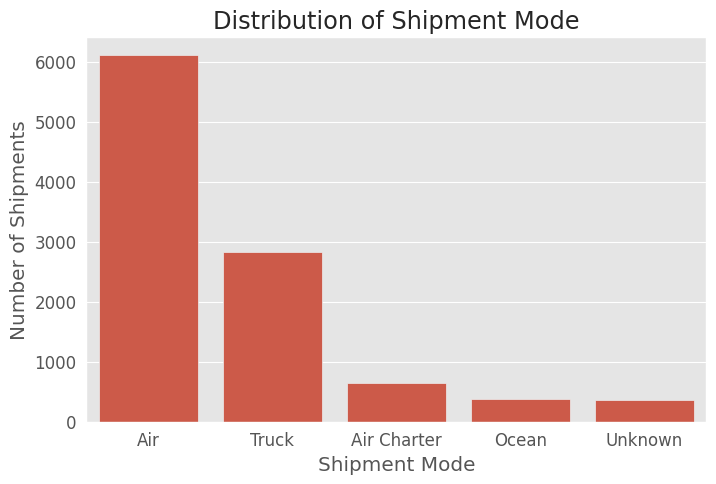

In [35]:
#Distribution of Shipment Mode

plt.figure(figsize = (8, 5))

sns.countplot(data = df, x = "Shipment Mode",
order = df["Shipment Mode"].value_counts().index)
plt.title("Distribution of Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Number of Shipments")
plt.show()

##Top 10 Destination Countries
###Why did I choose this chart?

A horizontal count plot is suitable for comparing shipment volumes across multiple destination countries. It makes it easy to identify the countries receiving the highest number of shipments.

###Insight

South Africa receives the highest number of shipments in the dataset.
Nigeria and Côte d'Ivoire are also major destination countries.
The top ten countries account for a significant share of the overall shipment volume, indicating that logistics operations are concentrated in a limited number of regions.

###Business Impact

Countries with the highest shipment volumes should receive greater attention in logistics planning and resource allocation.
FedEx can prioritize warehouse capacity, transportation resources, and vendor relationships in these key markets to improve delivery efficiency.
Since these countries handle a large proportion of shipments, even small improvements in delivery performance could have a meaningful impact on overall customer satisfaction and operational costs.

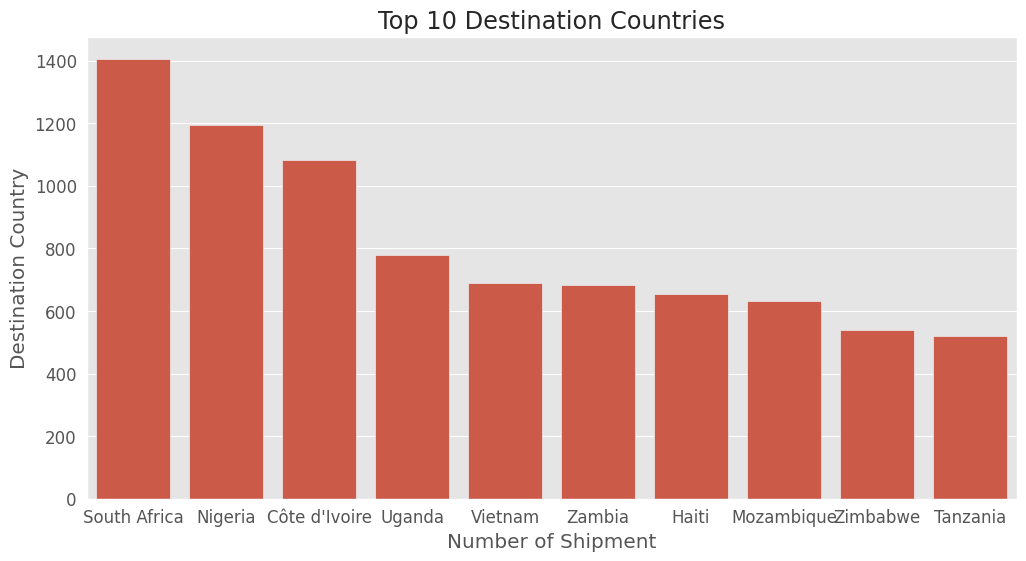

In [36]:
#Top 10 Destination Countries

plt.figure(figsize = (12,6))

sns.countplot( data = df, x = "Country", order = df["Country"].value_counts().head(10).index)

plt.title("Top 10 Destination Countries")
plt.xlabel("Number of Shipment")
plt.ylabel("Destination Country")
plt.show()

##Product Group Distribution
### Why did I choose this chart?

A count plot is used because Product Group is a categorical variable. It helps compare shipment volumes across different product categories.

### Insight

(We'll write after seeing the chart.)

### Business Impact

Understanding which product groups dominate shipments helps FedEx prioritize inventory planning, transportation resources, and supply chain management.

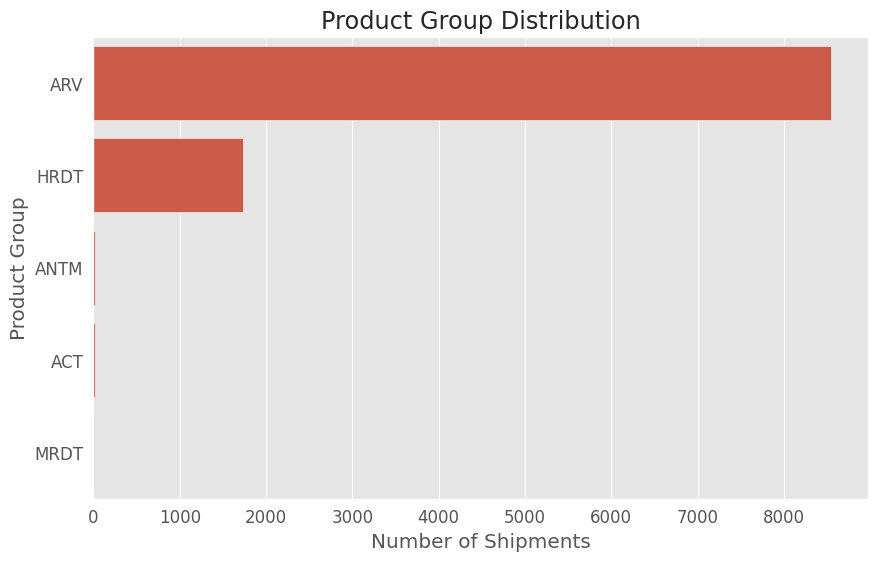

In [37]:
#Product Group Distribution
plt.figure(figsize = (10,6))

sns.countplot(data = df, y = "Product Group", order = df["Product Group"].value_counts().index)

plt.title("Product Group Distribution")
plt.xlabel("Number of Shipments")
plt.ylabel("Product Group")

plt.show()

##Vendor INCO Term Distribution
### Why did I choose this chart?

Vendor INCO Term is a categorical feature. A count plot helps identify the most commonly used shipping agreements.


### Business Impact

The dominant INCO terms indicate how logistics responsibilities are shared between vendors and customers. This helps evaluate procurement and shipping strategies.

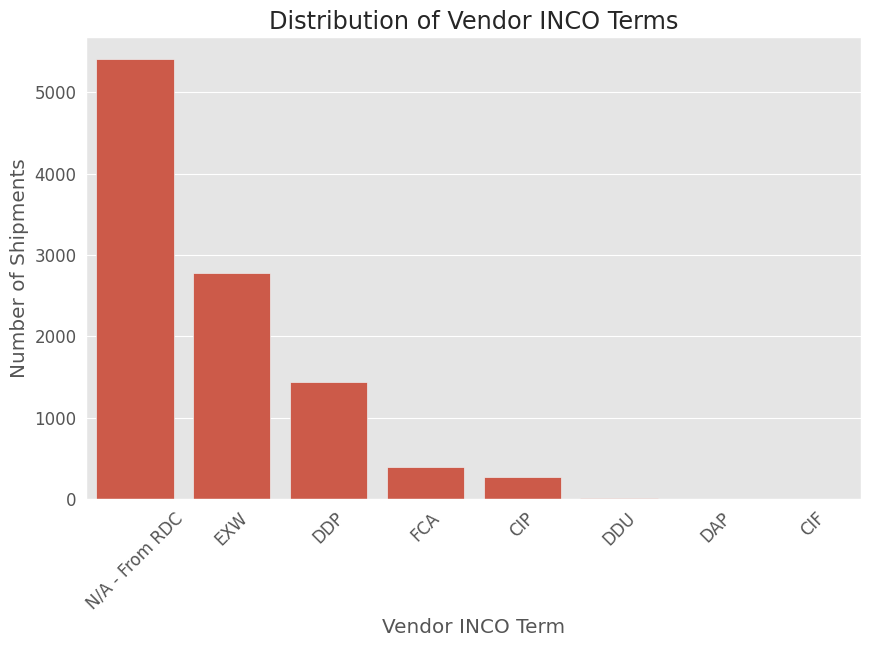

In [38]:
#Vendor INCO Term Distribution
plt.figure(figsize = (10,6))

sns.countplot(data = df, x = "Vendor INCO Term", order = df["Vendor INCO Term"].value_counts().index)

plt.title("Distribution of Vendor INCO Terms")
plt.xlabel("Vendor INCO Term")
plt.ylabel("Number of Shipments")

plt.xticks(rotation = 45)

plt.show()

##Distribution of Delivery Delay
###Why did I choose this chart?

Delivery Delay is a key performance metric. A histogram helps evaluate delivery performance by showing how delays are distributed.

###Insight
Most deliveries occur very close to the scheduled date (around 0 days delay).
There are shipments delivered earlier than scheduled (negative delay).
A smaller number of shipments experience significant delays.

###Business Impact
The logistics network generally performs well.
Late deliveries should be investigated to identify operational bottlenecks.
Reducing delays improves customer satisfaction and service quality.

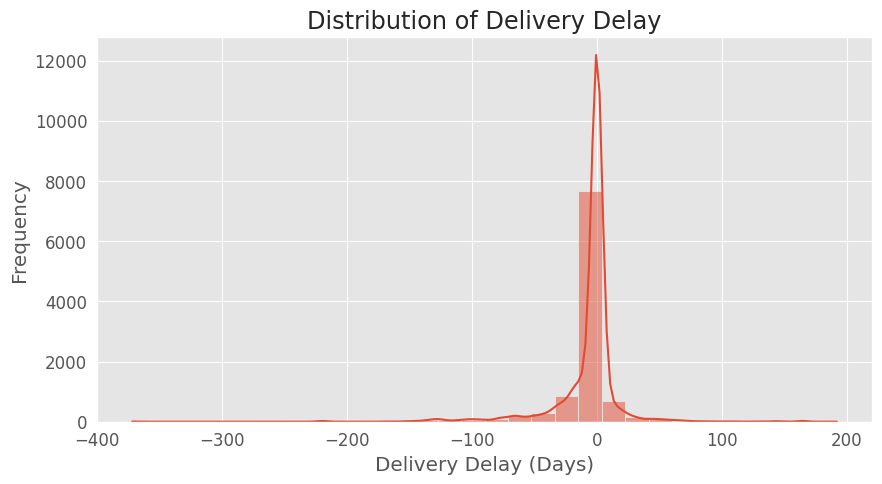

In [39]:
#Distribution of Delivery Delay
plt.figure(figsize=(10,5))

sns.histplot(
    df["Delivery Delay (Days)"],
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Delay")
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Frequency")

plt.show()

## Distribution of Freight Cost
###Why did I choose this chart?

Freight Cost is a numerical variable. A histogram helps identify the overall cost distribution and detect expensive shipments.

###Insight

Freight costs are also strongly right-skewed.
Most shipments incur relatively low transportation costs.
A few shipments have exceptionally high freight expenses.

###Business Impact

Management should investigate high-cost shipments.
Expensive routes or transportation methods can be optimized.
Understanding freight cost distribution helps reduce logistics expenses.

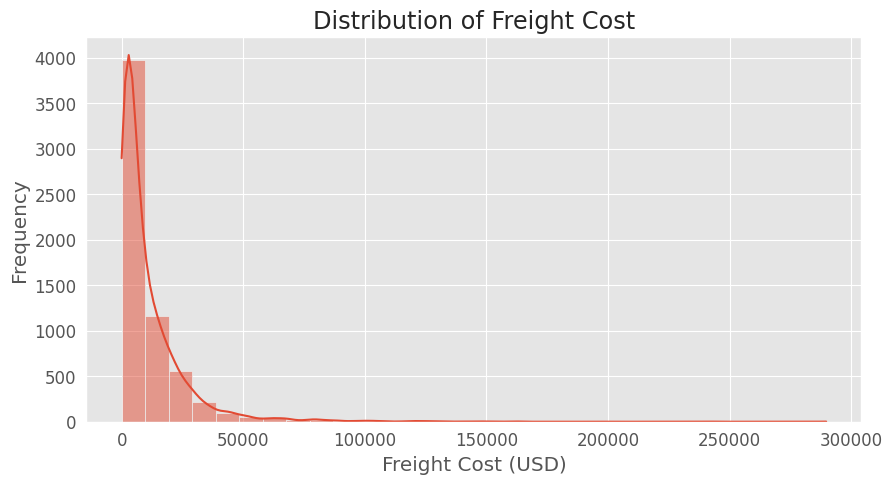

In [40]:
#Distribution of Freight Cost
plt.figure(figsize=(10,5))

sns.histplot(
    df["Freight Cost (USD)"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Freight Cost")
plt.xlabel("Freight Cost (USD)")
plt.ylabel("Frequency")

plt.show()

## Distribution of Line Item Value
###Why did I choose this chart?

A histogram with KDE is appropriate because Line Item Value is a continuous numerical variable. It helps us understand the distribution of shipment values and detect skewness and extreme-value orders.

###Insight

Most shipments have relatively low monetary value.
The distribution is highly right-skewed.
A small number of shipments have extremely large values (up to several million USD), indicating high-value orders.

###Business Impact

High-value shipments require additional monitoring and security.
These shipments may need premium logistics services and insurance.
Separate handling strategies can reduce financial risk and improve customer satisfaction.

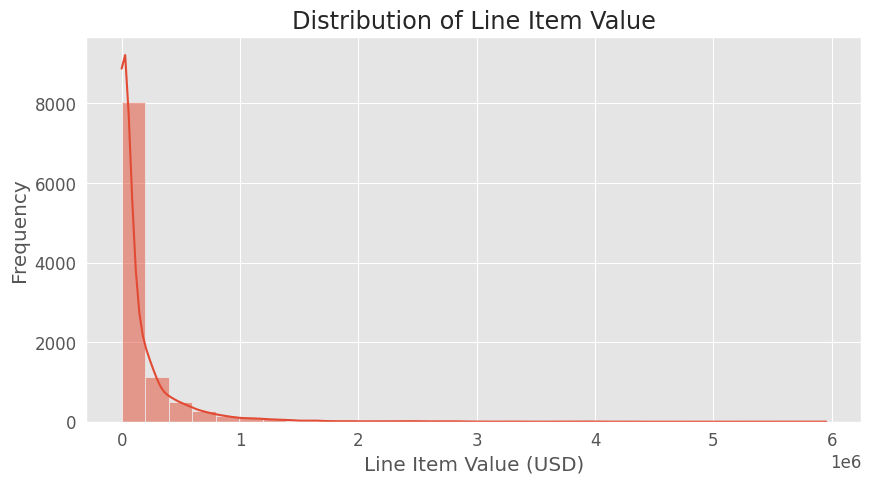

In [41]:
#Distribution of Line Item Value
plt.figure(figsize=(10,5))

sns.histplot(
    df["Line Item Value"],
    bins=30,
    kde=True
)

plt.title("Distribution of Line Item Value")
plt.xlabel("Line Item Value (USD)")
plt.ylabel("Frequency")

plt.show()

## Top 10 Brands
###Why did I choose this chart?

A horizontal bar chart is appropriate because Brand is a categorical variable with many unique values. Displaying only the top 10 brands makes the comparison easy to interpret.

###Insight

Generic products dominate the shipments by a very large margin.
Determine is the second most shipped brand but far behind Generic.
The remaining brands contribute only a small proportion of total shipments.

###Business Impact

Procurement teams should prioritize inventory planning for Generic medicines.
High-volume brands require stronger supplier relationships and higher safety stock.
Low-volume brands may be ordered only on demand to reduce inventory holding costs.

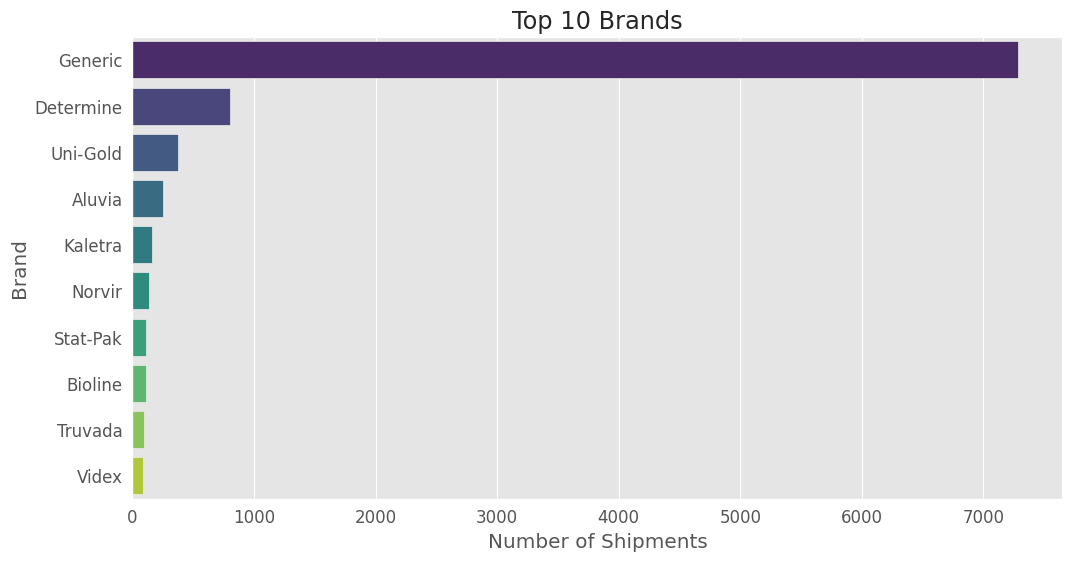

In [42]:
#Distribution of Brands
plt.figure(figsize = (12,6))

top_brand = df["Brand"].value_counts().head(10)

sns.barplot(x = top_brand.values ,
            y = top_brand.index ,
            hue = top_brand.index ,
            palette = "viridis",
            legend = False
            )
plt.title("Top 10 Brands")
plt.xlabel("Number of Shipments")
plt.ylabel("Brand")
plt.show()

## Top 10 Manufacturing Sites
###Why did I choose this chart?

A horizontal bar chart effectively compares shipment volumes across manufacturing locations.

##Insight

Aurobindo Unit III, India is the largest manufacturing site.
Other major contributors include Mylan, Hetero, and Cipla.
Most of the top manufacturing sites are located in India.

##Business Impact

Heavy dependence on a few manufacturing sites creates supply chain concentration risk.
Diversifying suppliers and production locations can improve supply chain resilience.
High-volume plants should receive priority in quality assurance and logistics planning.

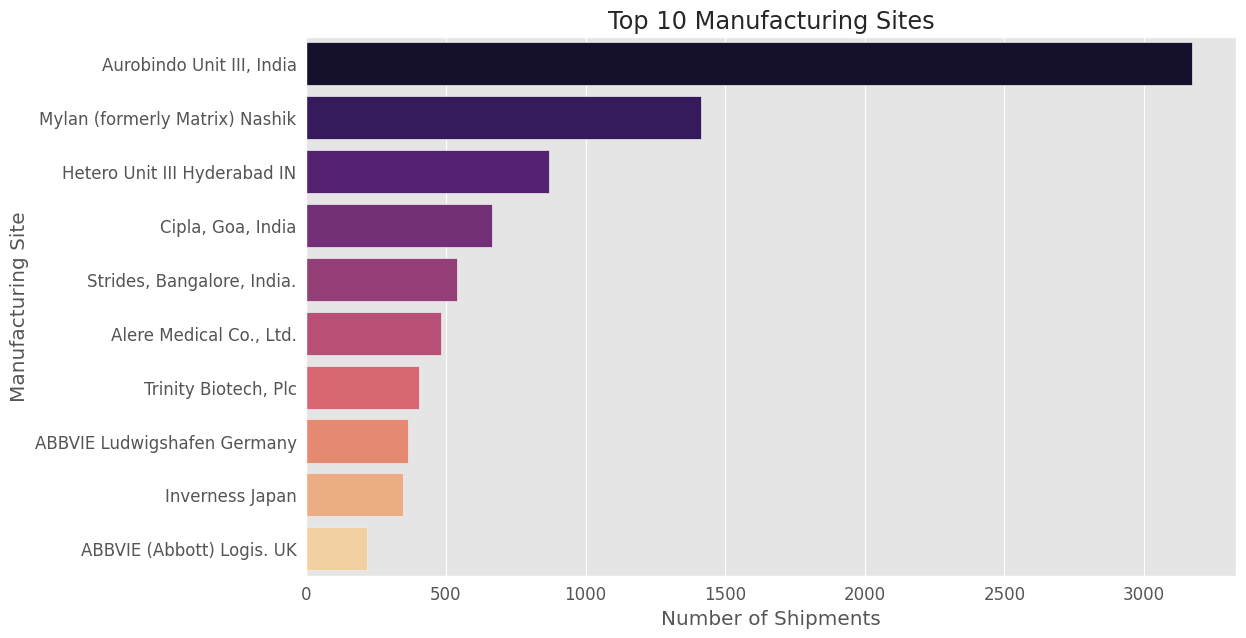

In [43]:
#Distribution of Manufacturing Site
plt.figure(figsize = (12, 7))
top_site = df["Manufacturing Site"].value_counts().head(10)

sns.barplot( x = top_site.values,
            y = top_site.index,
            hue = top_site.index,
            palette = "magma",
             legend = False)
plt.title("Top 10 Manufacturing Sites")
plt.xlabel("Number of Shipments")
plt.ylabel("Manufacturing Site")
plt.show()

## Distribution of Managed By
###Why did I choose this chart?

A count plot clearly compares the number of shipments managed by different management teams.

###Insight

Nearly all shipments are managed by PMO-US.
Regional field offices handle only a very small number of shipments.

###Business Impact

Centralized management simplifies coordination.
However, relying heavily on one management office may create an operational bottleneck.
Regional offices could be empowered to improve responsiveness and reduce workload.

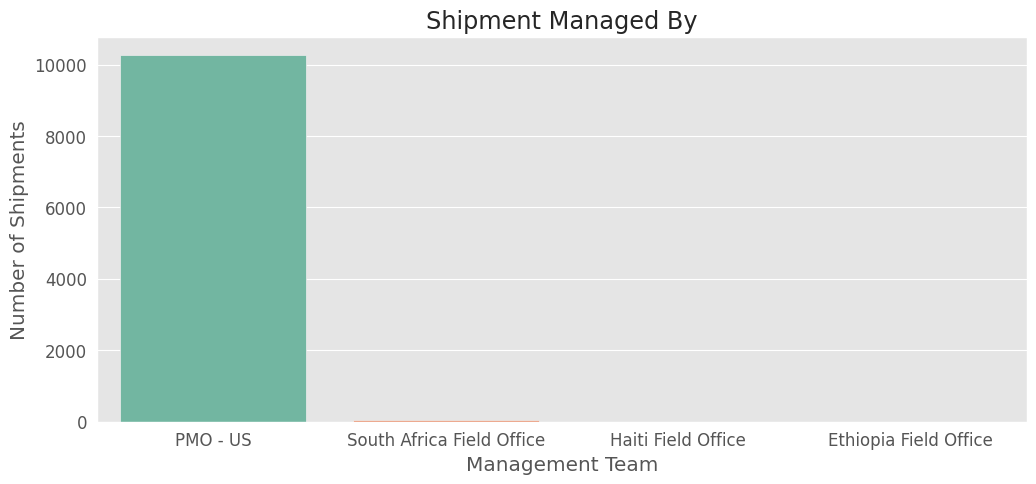

In [44]:
#Distribution of Managed By
plt.figure(figsize = (12,5))

sns.countplot( data = df,
             x = "Managed By",
              hue = "Managed By",
              palette ="Set2",
              legend = False)

plt.title("Shipment Managed By")
plt.xlabel("Management Team")
plt.ylabel("Number of Shipments")
plt.show()

##Delivery Status By Distribution
###Why did I choose this chart?

A count plot is suitable because Delivery Status is a binary categorical variable.

###Insight

The majority of shipments are delivered On Time.
Only a small percentage experience delays.

###Business Impact

Overall logistics performance appears strong.
The delayed shipments should be investigated to identify recurring causes such as transportation issues, customs delays, or supplier problems.

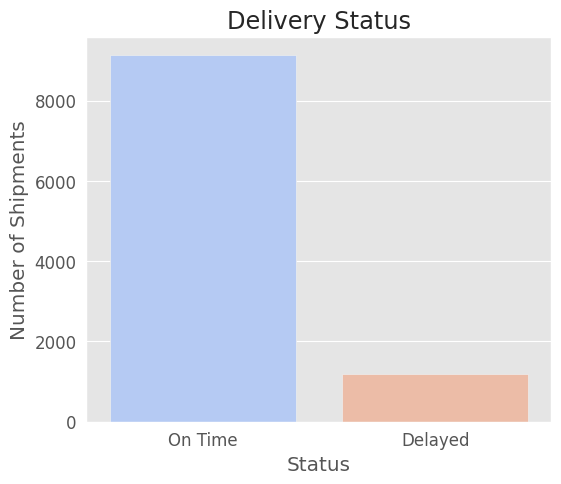

In [45]:
#Delivery Status Distribution
plt.figure(figsize = (6, 5))

sns.countplot(
    data=df,
    x="Delivery Status",
    hue="Delivery Status",
    palette="coolwarm",
    legend=False
)

plt.title("Delivery Status")
plt.xlabel("Status")
plt.ylabel("Number of Shipments")
plt.show()

###Processing Time Distribution
###Why did I choose this chart?

A histogram with KDE is ideal for analyzing the distribution of processing time.

###Insight

Most shipments require 50–150 days for processing.
The distribution is positively skewed.
A few shipments take much longer, exceeding 300 days.

###Business Impact

Long processing times may indicate procurement delays, supplier issues, or documentation bottlenecks.
Identifying and addressing these exceptional cases can improve overall supply chain efficiency.

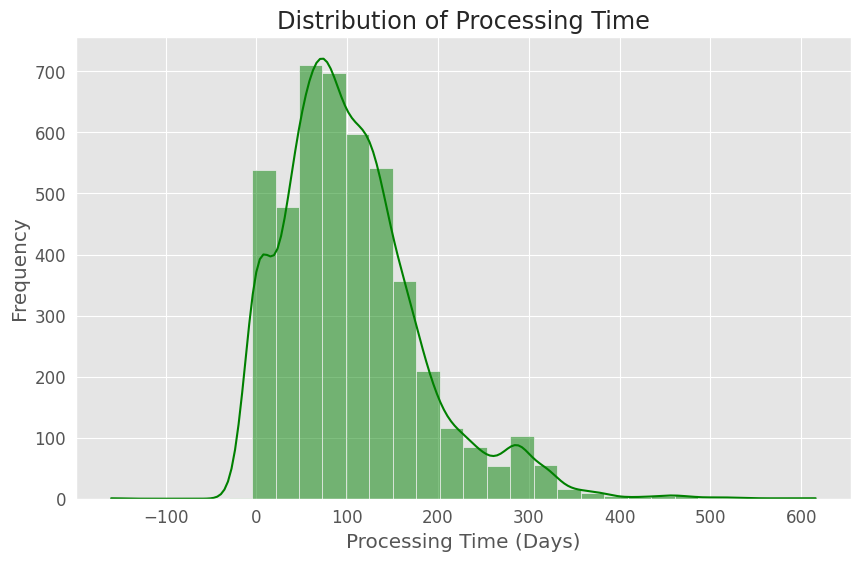

In [46]:
#Processing Time Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    df["Processing Time (Days)"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Distribution of Processing Time")
plt.xlabel("Processing Time (Days)")
plt.ylabel("Frequency")
plt.show()

###  Top 10 Countries by Shipment Value

#### Why this chart?
This chart identifies the countries receiving the highest total value of pharmaceutical shipments. It highlights key markets and helps understand where financial exposure is concentrated.

#### Key Insights
- Nigeria accounts for the highest shipment value by a significant margin.
- Zambia and Mozambique are the next largest recipients.
- Most high-value destinations are located in Africa.
- A few countries contribute a large proportion of the total shipment value.

#### Business Impact
- High-value destination countries should receive priority for supply chain planning and inventory allocation.
- Revenue concentration indicates higher financial risk if disruptions occur in these markets.
- Country-wise shipment value analysis supports strategic expansion and resource allocation decisions.

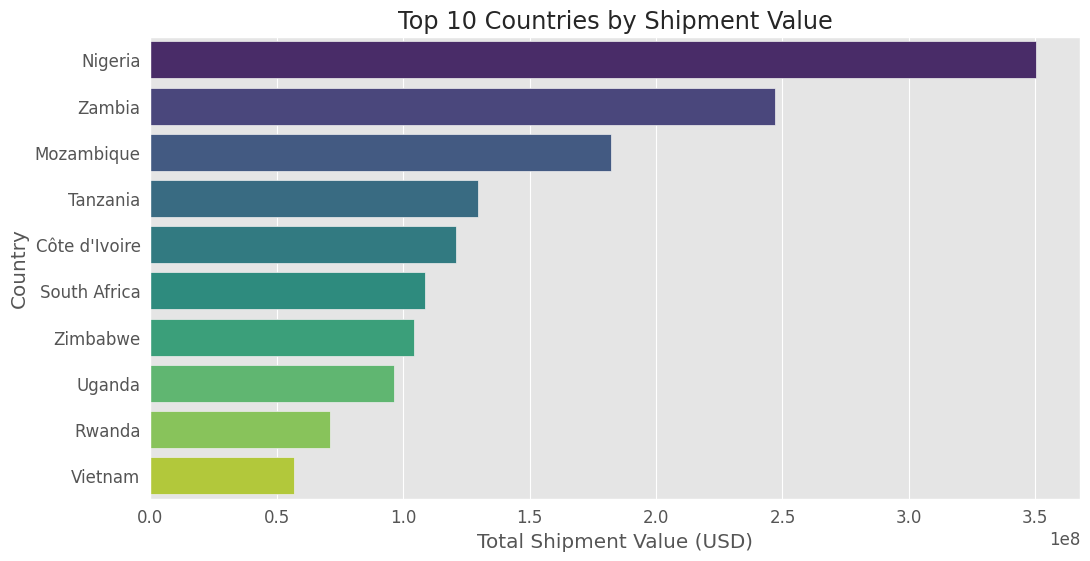

In [47]:
#Total Shipment Value by Country
country_value = (
    df.groupby("Country")["Line Item Value"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_value.values,
    y=country_value.index,
    palette="viridis"
)

plt.title("Top 10 Countries by Shipment Value")
plt.xlabel("Total Shipment Value (USD)")
plt.ylabel("Country")

plt.show()

###Average Freight Cost by Shipment Mode

#### Why this chart?
This visualization compares transportation costs across shipment modes to support logistics cost optimization.

#### Key Insights
- Air Charter has the highest average freight cost among all shipment modes.
- Ocean freight is the second most expensive transportation option.
- Air and Truck shipments have similar average freight costs.
- Unknown shipment mode records have the lowest reported freight cost.

#### Business Impact
- Air Charter should be reserved for urgent or high-priority shipments due to its high cost.
- Air and Truck provide a balance between transportation cost and delivery speed.
- Freight cost comparison supports cost-effective transportation planning and budget optimization.

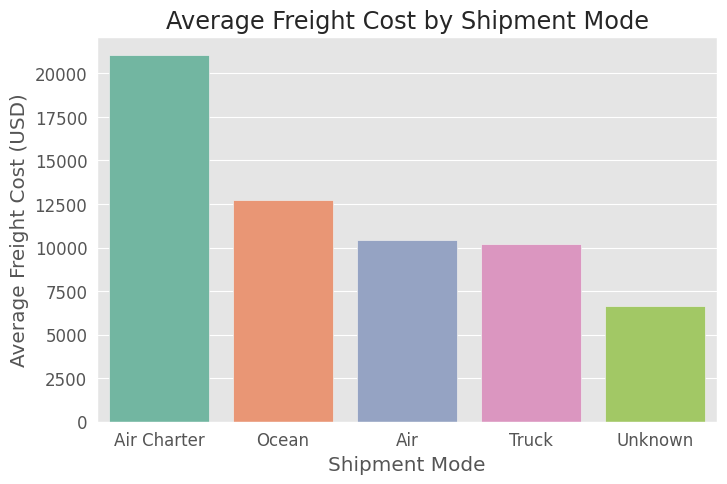

In [48]:
#Average Freight Cost by Shipment Mode
mode_freight = (
    df.groupby("Shipment Mode")["Freight Cost (USD)"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=mode_freight.index,
    y=mode_freight.values,
    palette="Set2"
)

plt.title("Average Freight Cost by Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Average Freight Cost (USD)")

plt.show()

## Average Delivery Delay by Shipment Mode

### Why this chart?
This chart compares the average delivery delay across different shipment modes to identify which transportation methods are the most time-efficient.

### Insights
- Ocean shipments show the highest positive average delay, indicating slower deliveries.
- Air and Air Charter shipments have negative average delays, meaning they generally arrive earlier than expected.
- Truck transportation also performs well with deliveries ahead of schedule.
- Air transportation provides the most consistent delivery performance.

### Business Impact
- Encourage greater use of Air or Truck transport for urgent shipments.
- Investigate causes of delays in Ocean shipments such as customs clearance, port congestion, or scheduling issues.
- Transportation mode selection can significantly improve customer satisfaction and reduce operational delays.

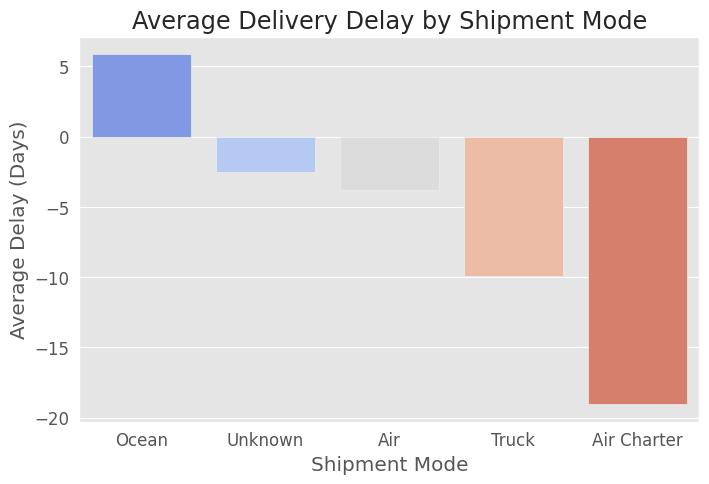

In [49]:
#Average Delivery Delay by Shipment Mode
delay_mode = (
    df.groupby("Shipment Mode")["Delivery Delay (Days)"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=delay_mode.index,
    y=delay_mode.values,
    palette="coolwarm"
)

plt.title("Average Delivery Delay by Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Average Delay (Days)")

plt.show()

## Shipment Volume by Year

### Why this chart?
This chart shows how shipment volumes changed over time, helping identify business growth patterns and changes in operational demand.

### Insights
- Shipment volume increased rapidly during the early years of the dataset.
- Peak shipment activity occurred around 2014.
- A decline is observed in the final year, which may indicate incomplete yearly data rather than an actual decrease.
- Overall, the organization experienced strong long-term growth in shipment operations.

### Business Impact
- Historical shipment trends help management forecast future logistics requirements.
- Capacity planning can be aligned with expected shipment growth.
- Significant increases in shipment volume require expansion of warehouse, transportation, and procurement resources.

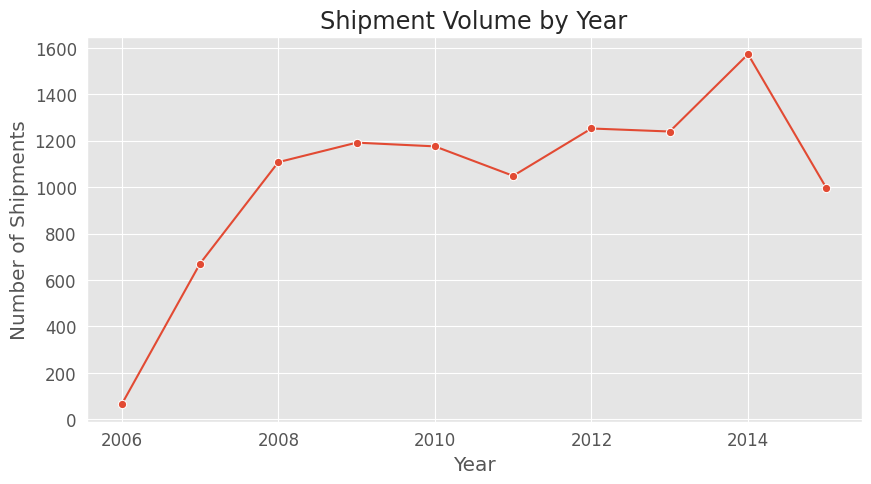

In [50]:
#Shipment Volume by Year
year_shipments = (
    df["Delivery Year"]
      .value_counts()
      .sort_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=year_shipments.index,
    y=year_shipments.values,
    marker="o"
)

plt.title("Shipment Volume by Year")
plt.xlabel("Year")
plt.ylabel("Number of Shipments")

plt.show()

## Monthly Shipment Trend

### Why this chart?
This chart analyzes seasonal shipment patterns throughout the year to identify peak and low shipment periods.

### Insights
- Shipment volume varies noticeably across different months.
- August records the highest shipment activity.
- January and December have comparatively lower shipment volumes.
- The organization experiences clear seasonal fluctuations in logistics demand.

### Business Impact
- High-demand months require additional transportation capacity and workforce planning.
- Procurement teams can prepare inventory in advance of peak shipment periods.
- Understanding seasonality improves resource allocation and reduces operational bottlenecks.

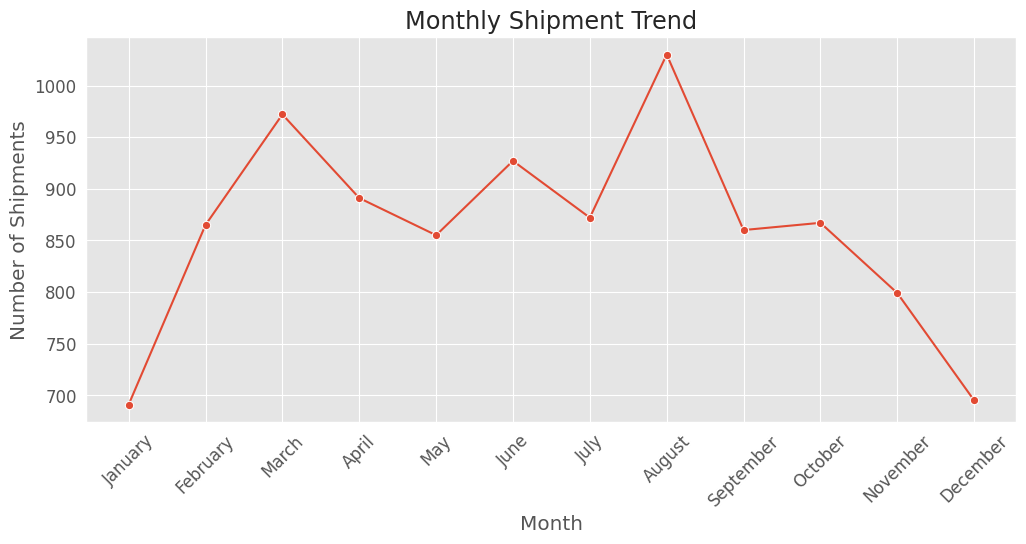

In [51]:
#Monthly Shipment Trend
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = (
    df["Delivery Month"]
      .value_counts()
      .reindex(month_order)
)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Shipment Trend")
plt.xlabel("Month")
plt.ylabel("Number of Shipments")

plt.show()

## Average Processing Time by Country

### Why this chart?
This chart identifies countries where shipment processing takes the longest, helping locate operational inefficiencies across regions.

### Insights
- Pakistan has the highest average processing time among all countries.
- Guatemala and Afghanistan also experience relatively long processing durations.
- Significant differences exist between countries, suggesting regional operational challenges.
- Processing efficiency varies considerably across the supply chain network.

### Business Impact
- Countries with long processing times should be prioritized for operational improvements.
- Local administrative procedures, customs processes, and warehouse operations should be reviewed.
- Reducing processing time improves delivery speed, lowers inventory holding costs, and enhances customer satisfaction.

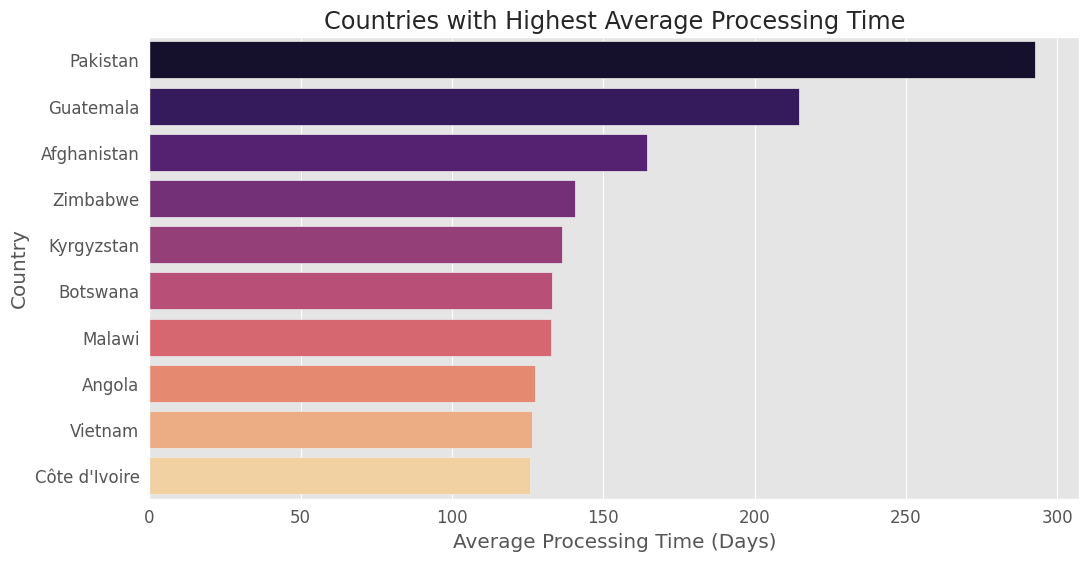

In [52]:
#Average Processing Time by Country
country_processing = (
    df.groupby("Country")["Processing Time (Days)"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_processing.values,
    y=country_processing.index,
    palette="magma"
)

plt.title("Countries with Highest Average Processing Time")
plt.xlabel("Average Processing Time (Days)")
plt.ylabel("Country")

plt.show()

## Vendors Contributing Highest Shipment Value

#### Why this chart?
This chart identifies suppliers responsible for the largest procurement value, enabling better supplier management and procurement planning.

#### Insights
- SCMS from RDC contributes an exceptionally large share of total shipment value.
- The remaining vendors contribute substantially smaller shipment values.
- Shipment value is highly concentrated among a limited number of suppliers.
- Vendor dependency is evident within the procurement network.

#### Business Impact
Heavy reliance on a single supplier increases supply chain risk. Diversifying procurement across additional vendors can improve resilience, reduce disruption risk, and strengthen negotiation power.

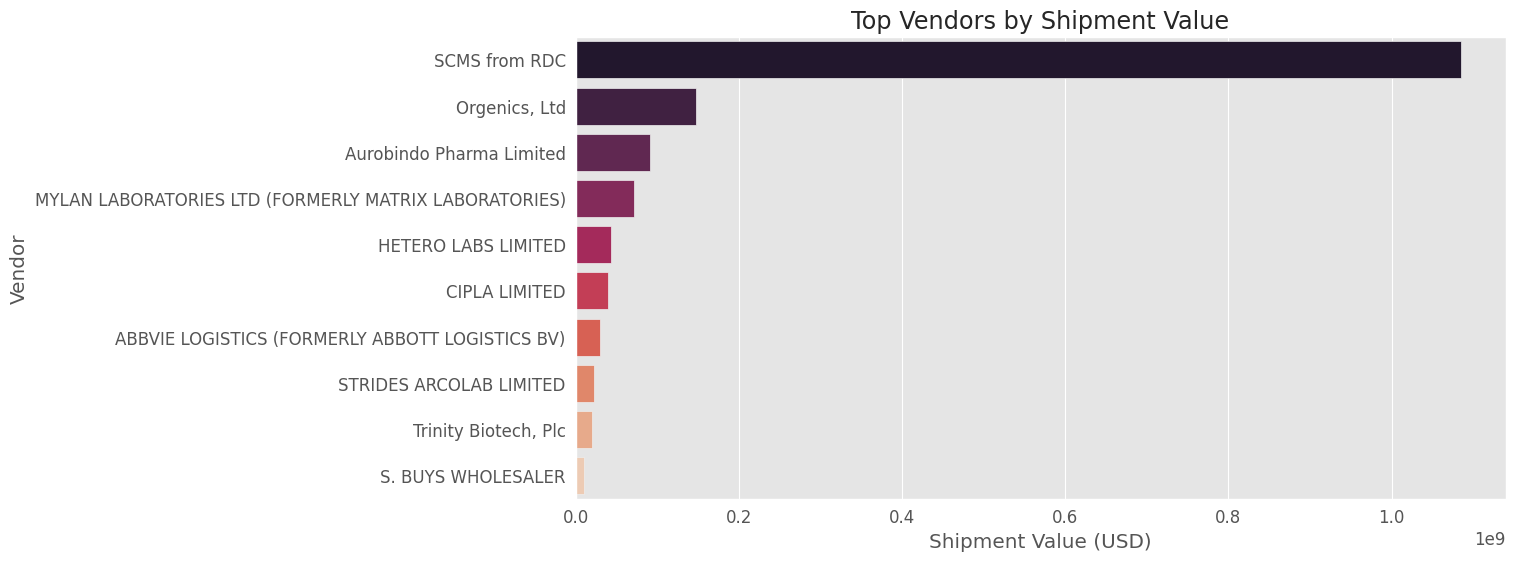

In [53]:
#Top Vendors by Shipment Value
vendor_value = (
    df.groupby("Vendor")["Line Item Value"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=vendor_value.values,
    y=vendor_value.index,
    palette="rocket"
)

plt.title("Top Vendors by Shipment Value")
plt.xlabel("Shipment Value (USD)")
plt.ylabel("Vendor")

plt.show()

## Relationship Between Freight Cost and Shipment Value

#### Why this chart?
This scatter plot examines whether higher-value shipments incur proportionally higher freight costs and identifies cost variability across shipments.

#### Insights
- Most shipments are concentrated at relatively low shipment values and moderate freight costs.
- Freight cost increases with shipment value only up to a certain point.
- Significant variability exists among shipments with similar values, indicating inconsistent transportation expenses.
- Several outliers exhibit exceptionally high freight costs despite moderate shipment values.

#### Business Impact
Transportation expenses are influenced by multiple operational factors beyond shipment value, such as destination, transportation mode, and urgency. Investigating high-cost outliers can identify opportunities for logistics cost optimization.

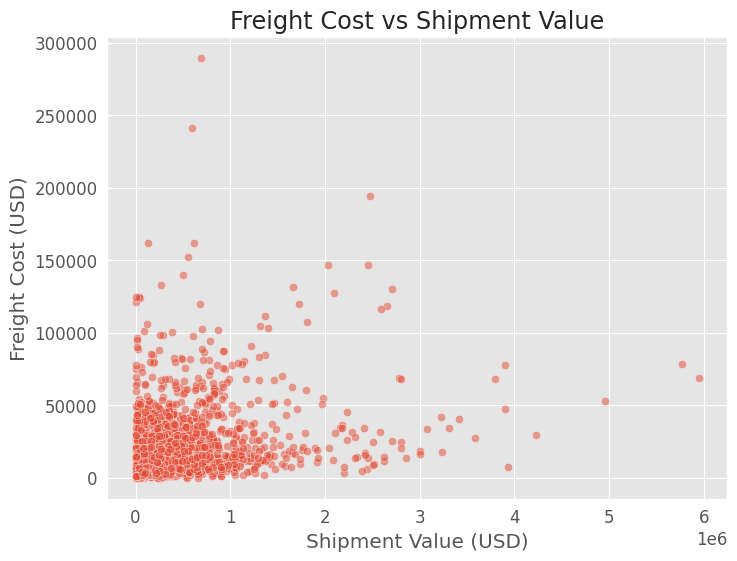

In [54]:
#Freight Cost vs Shipment Value
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Line Item Value",
    y="Freight Cost (USD)",
    alpha=0.5
)

plt.title("Freight Cost vs Shipment Value")
plt.xlabel("Shipment Value (USD)")
plt.ylabel("Freight Cost (USD)")

plt.show()

## Delivery Performance Across Transportation Modes

#### Why this chart?
This visualization compares on-time and delayed shipments across different transportation modes to evaluate operational reliability.

#### Insights
- Air shipments account for the largest shipment volume and maintain a high on-time delivery rate.
- Truck shipments also perform well with relatively few delays.
- Air Charter experiences a higher proportion of delayed deliveries despite handling fewer shipments.
- Ocean shipments have comparatively low shipment volume and limited delays.
- Unknown shipment modes contribute very little to overall logistics operations.

#### Business Impact
Air and Truck transportation remain the most dependable shipping methods for routine operations. Air Charter should be reserved for exceptional situations where urgency outweighs higher costs and operational uncertainty.

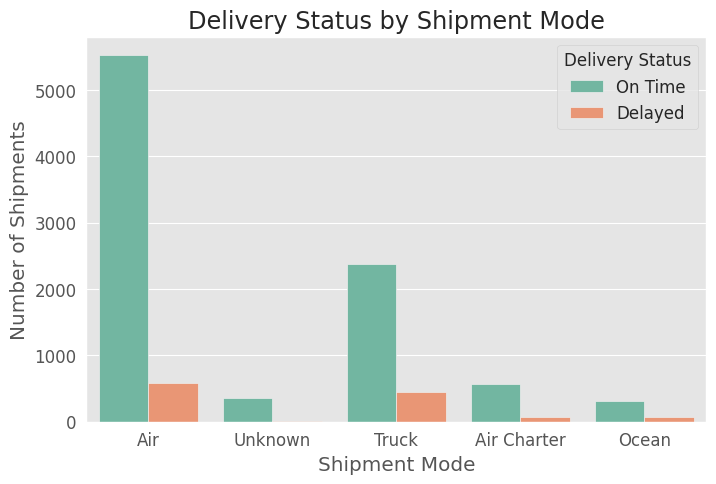

In [55]:
#Shipment Mode vs Delivery Status
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Shipment Mode",
    hue="Delivery Status",
    palette="Set2"
)

plt.title("Delivery Status by Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Number of Shipments")

plt.show()

## Correlation Heatmap
### Why this chart?
This heatmap identifies relationships between key numerical variables such as shipment value, freight cost, quantity, weight, processing time, and delivery delay. Understanding these relationships helps determine the major drivers of logistics cost and operational performance.

### Insights
- Line Item Quantity and Line Item Value show a strong positive correlation (0.84), indicating larger orders naturally have higher shipment values.
- Freight Cost has only a moderate relationship with shipment value and weight.
- Delivery Delay has almost no correlation with freight cost, shipment value, or quantity.
- Unit Price and Pack Price show only a weak positive relationship.
- Processing Time has very weak correlation with most operational variables.

### Business Impact
The analysis suggests that delivery delays are likely caused by operational inefficiencies rather than shipment size or freight expenditure. Cost optimization efforts should focus on improving logistics planning and supplier coordination rather than simply increasing transportation budgets.

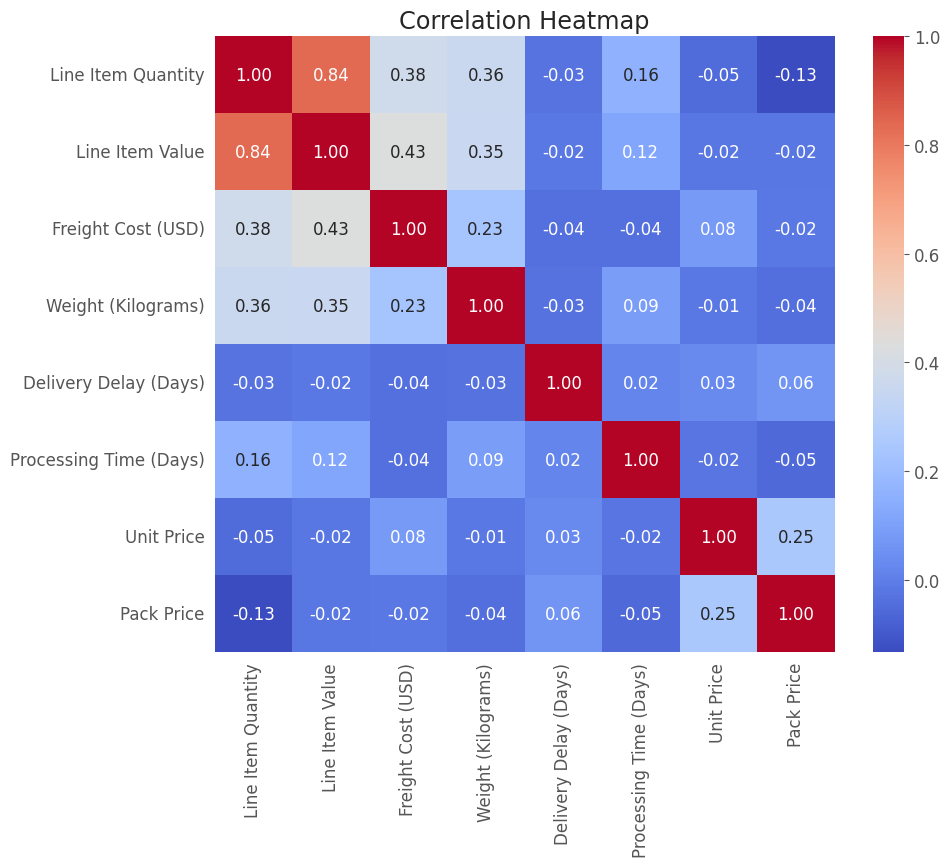

In [56]:
#Correlation Heatmap
numeric_cols = [
    "Line Item Quantity",
    "Line Item Value",
    "Freight Cost (USD)",
    "Weight (Kilograms)",
    "Delivery Delay (Days)",
    "Processing Time (Days)",
    "Unit Price",
    "Pack Price"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Executive Summary

## Project Objective

The objective of this project was to analyze global pharmaceutical shipment operations to identify patterns affecting logistics efficiency, delivery performance, procurement, and transportation costs.

---

## Key Findings

- Air transportation handled the majority of shipments while maintaining strong delivery performance.
- Most deliveries were completed on time, indicating an efficient logistics network.
- Shipment processing time typically ranged between 50 and 150 days, with a small number of significant delays.
- Shipment volume peaked during August, suggesting seasonal procurement activity.
- Nigeria and several African countries represented the highest shipment values.
- Pakistan and Guatemala experienced the longest average processing times, highlighting potential operational bottlenecks.
- Air Charter transportation generated the highest average freight cost while offering limited operational advantages.
- Procurement spending was concentrated among a few major vendors, increasing supplier dependency.
- Correlation analysis revealed that delivery delays were largely independent of shipment value or freight cost, indicating that operational processes rather than shipment size drive delays.

---

## Business Recommendations

- Investigate countries with consistently high processing times to reduce operational delays.
- Optimize the use of Air Charter transportation for only high-priority shipments.
- Diversify supplier relationships to minimize procurement concentration risk.
- Analyze high freight-cost outliers to identify opportunities for transportation cost reduction.
- Use seasonal shipment trends for inventory forecasting and capacity planning.
- Strengthen logistics coordination to improve processing efficiency rather than simply increasing transportation expenditure.




# Conclusion

The analysis demonstrates that the pharmaceutical supply chain operates efficiently overall, with strong on-time delivery performance. However, opportunities remain to reduce processing delays, optimize transportation costs, diversify suppliers, and strengthen logistics planning. These improvements can increase operational resilience while supporting more cost-effective global healthcare distribution.

In [57]:
df.to_csv("fedex_cleaned.csv", index=False)